# Breast Cancer Gene Expression Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)

## 1. Dataset Acquisition

In [2]:
import gzip

file_path = "../data/GSE42568_series_matrix.txt.gz"

with gzip.open(file_path, "rt", encoding="utf-8") as f:
    lines = f.readlines()

print("Total lines:", len(lines))


Total lines: 54755


In [3]:
import gzip

file_path = "../data/GSE42568_series_matrix.txt.gz"

with gzip.open(file_path, "rt", encoding="utf-8") as f:
    for i in range(20):
        print(f.readline())
        

!Series_title	"Breast Cancer Gene Expression Analysis"

!Series_geo_accession	"GSE42568"

!Series_status	"Public on May 26 2013"

!Series_submission_date	"Nov 27 2012"

!Series_last_update_date	"Mar 25 2019"

!Series_pubmed_id	"23740839"

!Series_summary	"Analysis of 104 breast cancer biopsies (removed prior to any treatment with tamoxifen or chemotherapeutic agents) from patients aged between 31 years and 89 years at the time of diagnosis (mean age = 58 years). Twenty were less than 50 years and seventy-seven women were 50 years, or older, at diagnosis. The size of the tumours ranged between 0.6 cm and 8.0 cm (mean = 2.79 cm). Eighteen tumours were T1 (<2 cm) in maximal dimension; 83 were T2 (2–5 cm) and 3 tumours were T3 (>5 cm). Eighty-two were invasive ductal carcinoma, 17 were invasive lobular and five were tumours of special type (two tubular and three mucinous). Eleven tumours were grade 1; 40 were grade 2; and 53 were grade 3. Sixty-seven tumours were oestrogen receptor (ER) po

## 2. Data Loading and Preprocessing

In [4]:
for i, line in enumerate(lines):
    if line.startswith("ID_REF"):
        print("Found expression matrix at line:", i)
        print(line[:200])
        break

In [5]:
i = 0  # 1. Start a manual counter at 0
for line in lines:
    if "ID_REF" in line:
        print("Found at line", i)
        print(line[:300])
        break
    i += 1  # 2. Manually add 1 at the end of every loop

Found at line 78
"ID_REF"	"GSM1045191"	"GSM1045192"	"GSM1045193"	"GSM1045194"	"GSM1045195"	"GSM1045196"	"GSM1045197"	"GSM1045198"	"GSM1045199"	"GSM1045200"	"GSM1045201"	"GSM1045202"	"GSM1045203"	"GSM1045204"	"GSM1045205"	"GSM1045206"	"GSM1045207"	"GSM1045208"	"GSM1045209"	"GSM1045210"	"GSM1045211"	"GSM1045212"	"GSM1


In [6]:
import pandas as pd

expr = pd.read_csv(
    "../data/GSE42568_series_matrix.txt.gz",
    sep="\t",
    skiprows=78,
    compression="gzip"
)

print(expr.shape)
expr.head(-1)

(54676, 122)


,ID_REF,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,...,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
0,1007_s_at,5.640239,3.557696,3.132007,6.865108,4.955184,5.573674,4.714100,5.234298,5.050853,...,6.953623,7.007825,7.867141,8.436528,6.020774,7.168925,7.935322,6.937005,8.822155,7.834706
1,1053_at,5.074866,4.984593,5.109481,5.473609,5.348400,5.572707,5.675239,5.792026,6.185706,...,5.453186,5.572707,5.471505,6.830667,6.855478,5.358832,4.804079,5.488895,5.575357,5.687899
2,117_at,4.191770,4.269061,4.131843,3.616546,4.296657,4.184048,4.000772,4.984939,4.958126,...,4.209247,3.946714,5.186979,3.888039,4.131843,4.131843,3.967933,4.392234,4.269244,4.264560
3,121_at,3.574706,4.065623,3.574706,3.574706,3.799293,3.803312,3.643243,4.053245,3.574706,...,3.574706,3.574706,3.574706,3.574706,3.574706,3.502410,3.574706,3.579242,3.574706,3.574706
4,1255_g_at,2.312812,2.409371,2.312812,2.312812,2.349630,2.312812,2.312812,2.312812,2.312812,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54670,AFFX-ThrX-5_at,5.152432,10.401430,10.409900,7.505545,5.964108,4.276242,4.139236,4.807221,3.680959,...,8.075797,3.512888,3.551799,3.472064,3.960255,3.697247,3.966759,3.551799,3.828618,4.051513
54671,AFFX-ThrX-M_at,7.779721,13.137754,13.120571,10.674244,8.416851,6.913481,7.757142,7.842519,6.774707,...,11.138814,7.266111,5.704393,5.948574,7.421387,5.885597,7.092354,7.665000,7.098040,6.686323
54672,AFFX-TrpnX-3_at,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.336713
54673,AFFX-TrpnX-5_at,2.312812,2.560414,2.460930,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,...,2.454202,2.312812,2.312812,2.312812,2.314241,2.312812,2.312812,2.312812,2.312812,2.312812


In [7]:
expr = expr[expr["ID_REF"] != "!series_matrix_table_end"]

In [8]:
expr.shape

(54675, 122)

In [9]:
print(expr.columns[:5])

Index(['ID_REF', 'GSM1045191', 'GSM1045192', 'GSM1045193', 'GSM1045194'], dtype='str')


In [10]:
print(expr.iloc[:5, :5])

      ID_REF  GSM1045191  GSM1045192  GSM1045193  GSM1045194
0  1007_s_at    5.640239    3.557696    3.132007    6.865108
1    1053_at    5.074866    4.984593    5.109481    5.473609
2     117_at    4.191770    4.269061    4.131843    3.616546
3     121_at    3.574706    4.065623    3.574706    3.574706
4  1255_g_at    2.312812    2.409371    2.312812    2.312812


In [11]:
expr.iloc[:,1:] = expr.iloc[:,1:].apply(pd.to_numeric, errors="coerce")

In [12]:
expr.info()

<class 'pandas.DataFrame'>
RangeIndex: 54675 entries, 0 to 54674
Columns: 122 entries, ID_REF to GSM1045311
dtypes: float64(121), str(1)
memory usage: 51.4 MB


In [13]:
n_genes = expr.shape[0]
n_samples = expr.shape[1] - 1

print("Genes:", n_genes)
print("Samples:", n_samples)

Genes: 54675
Samples: 121


In [14]:
print(expr.shape)
print(expr.columns[:5])

(54675, 122)
Index(['ID_REF', 'GSM1045191', 'GSM1045192', 'GSM1045193', 'GSM1045194'], dtype='str')


In [15]:
print(expr.iloc[0:1,0:5])

      ID_REF  GSM1045191  GSM1045192  GSM1045193  GSM1045194
0  1007_s_at    5.640239    3.557696    3.132007    6.865108


In [16]:
print(expr.iloc[0,0:5])

ID_REF        1007_s_at
GSM1045191     5.640239
GSM1045192     3.557696
GSM1045193     3.132007
GSM1045194     6.865108
Name: 0, dtype: object


In [17]:
expr = expr.set_index("ID_REF")

In [18]:
expr.head()


,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,GSM1045200,...,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.640239,3.557696,3.132007,6.865108,4.955184,5.573674,4.714100,5.234298,5.050853,6.913114,...,6.953623,7.007825,7.867141,8.436528,6.020774,7.168925,7.935322,6.937005,8.822155,7.834706
1053_at,5.074866,4.984593,5.109481,5.473609,5.348400,5.572707,5.675239,5.792026,6.185706,5.230088,...,5.453186,5.572707,5.471505,6.830667,6.855478,5.358832,4.804079,5.488895,5.575357,5.687899
117_at,4.191770,4.269061,4.131843,3.616546,4.296657,4.184048,4.000772,4.984939,4.958126,3.554531,...,4.209247,3.946714,5.186979,3.888039,4.131843,4.131843,3.967933,4.392234,4.269244,4.264560
121_at,3.574706,4.065623,3.574706,3.574706,3.799293,3.803312,3.643243,4.053245,3.574706,3.580369,...,3.574706,3.574706,3.574706,3.574706,3.574706,3.502410,3.574706,3.579242,3.574706,3.574706
1255_g_at,2.312812,2.409371,2.312812,2.312812,2.349630,2.312812,2.312812,2.312812,2.312812,2.312812,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812


In [19]:
expr = expr.apply(pd.to_numeric, errors="coerce")

In [20]:
expr.head()

,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,GSM1045200,...,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.640239,3.557696,3.132007,6.865108,4.955184,5.573674,4.714100,5.234298,5.050853,6.913114,...,6.953623,7.007825,7.867141,8.436528,6.020774,7.168925,7.935322,6.937005,8.822155,7.834706
1053_at,5.074866,4.984593,5.109481,5.473609,5.348400,5.572707,5.675239,5.792026,6.185706,5.230088,...,5.453186,5.572707,5.471505,6.830667,6.855478,5.358832,4.804079,5.488895,5.575357,5.687899
117_at,4.191770,4.269061,4.131843,3.616546,4.296657,4.184048,4.000772,4.984939,4.958126,3.554531,...,4.209247,3.946714,5.186979,3.888039,4.131843,4.131843,3.967933,4.392234,4.269244,4.264560
121_at,3.574706,4.065623,3.574706,3.574706,3.799293,3.803312,3.643243,4.053245,3.574706,3.580369,...,3.574706,3.574706,3.574706,3.574706,3.574706,3.502410,3.574706,3.579242,3.574706,3.574706
1255_g_at,2.312812,2.409371,2.312812,2.312812,2.349630,2.312812,2.312812,2.312812,2.312812,2.312812,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812


In [21]:
expr_t = expr.T

In [22]:
print(expr_t.shape)

(121, 54675)


In [23]:
expr_t.head()


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM1045191,5.640239,5.074866,4.191770,3.574706,2.312812,5.474018,7.392011,2.545487,6.363695,2.312812,...,13.900585,13.491092,14.891877,14.749976,10.053204,5.152432,7.779721,2.312812,2.312812,2.312812
GSM1045192,3.557696,4.984593,4.269061,4.065623,2.409371,5.246784,6.061380,2.312812,6.886877,2.366071,...,14.694493,14.482319,15.177010,15.107731,14.600338,10.401430,13.137754,2.312812,2.560414,2.312812
GSM1045193,3.132007,5.109481,4.131843,3.574706,2.312812,6.460169,5.862504,2.312812,4.953922,2.312812,...,14.528211,14.321748,15.195278,15.129354,14.114741,10.409900,13.120571,2.312812,2.460930,2.312812
GSM1045194,6.865108,5.473609,3.616546,3.574706,2.312812,5.146087,5.954431,2.312812,5.044880,2.312812,...,14.891396,14.796693,15.357952,15.360100,12.696520,7.505545,10.674244,2.312812,2.312812,2.312812
GSM1045195,4.955184,5.348400,4.296657,3.799293,2.349630,5.823408,7.679896,2.342446,5.468036,2.312812,...,14.307755,13.950866,15.133403,15.021234,10.747295,5.964108,8.416851,2.312812,2.312812,2.312812


In [24]:
for i in range(60):
    print(lines[i])

!Series_title	"Breast Cancer Gene Expression Analysis"

!Series_geo_accession	"GSE42568"

!Series_status	"Public on May 26 2013"

!Series_submission_date	"Nov 27 2012"

!Series_last_update_date	"Mar 25 2019"

!Series_pubmed_id	"23740839"

!Series_summary	"Analysis of 104 breast cancer biopsies (removed prior to any treatment with tamoxifen or chemotherapeutic agents) from patients aged between 31 years and 89 years at the time of diagnosis (mean age = 58 years). Twenty were less than 50 years and seventy-seven women were 50 years, or older, at diagnosis. The size of the tumours ranged between 0.6 cm and 8.0 cm (mean = 2.79 cm). Eighteen tumours were T1 (<2 cm) in maximal dimension; 83 were T2 (2–5 cm) and 3 tumours were T3 (>5 cm). Eighty-two were invasive ductal carcinoma, 17 were invasive lobular and five were tumours of special type (two tubular and three mucinous). Eleven tumours were grade 1; 40 were grade 2; and 53 were grade 3. Sixty-seven tumours were oestrogen receptor (ER) po

In [25]:
for i in range(60, 90):
    print(lines[i])

!Sample_label_protocol_ch1	"100 ng of each specimen was amplified and labelled using the Affymetrix GeneChip Eukaryotic 2 Cycle Labelling Assays for Expression Analysis, (Affymetrix; 900494) according to the manufacturer's instructions (www.affymetrix.com/products/reagents/specific/cdna2.affx)."	"100 ng of each specimen was amplified and labelled using the Affymetrix GeneChip Eukaryotic 2 Cycle Labelling Assays for Expression Analysis, (Affymetrix; 900494) according to the manufacturer's instructions (www.affymetrix.com/products/reagents/specific/cdna2.affx)."	"100 ng of each specimen was amplified and labelled using the Affymetrix GeneChip Eukaryotic 2 Cycle Labelling Assays for Expression Analysis, (Affymetrix; 900494) according to the manufacturer's instructions (www.affymetrix.com/products/reagents/specific/cdna2.affx)."	"100 ng of each specimen was amplified and labelled using the Affymetrix GeneChip Eukaryotic 2 Cycle Labelling Assays for Expression Analysis, (Affymetrix; 900494)

In [26]:
labels = ["Normal"] * 17 + ["Cancer"] * 104

expr_t["Label"] = labels

expr_t.head()
expr_t["Label"].value_counts()

Label
Cancer    104
Normal     17
Name: count, dtype: int64

## 4. Principal Component Analysis (PCA)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = expr_t.drop("Label", axis=1)

y = expr_t["Label"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Variance explained:",
    pca.explained_variance_ratio_
)

print(X_pca)

Variance explained: [0.11887502 0.07123524]
[[-5.57480966e+01  1.17548558e+02]
 [ 1.88902884e+02  1.17196106e+02]
 [ 2.73652997e+02  8.46053348e+01]
 [ 1.85360536e+02  7.19883853e+01]
 [-6.79204308e+01  1.47453121e+02]
 [-1.04135938e+02  1.68952466e+02]
 [-7.82303052e+01  1.63281698e+02]
 [-6.51563079e+01  1.55690859e+02]
 [-1.03152201e+02  1.75735488e+02]
 [-3.59951988e+01  9.10344428e+01]
 [-1.54360748e+01  1.02582381e+02]
 [-1.10995527e+02  1.49870444e+02]
 [ 3.37456509e+01  1.39793386e+02]
 [-9.20952376e+01  1.68984145e+02]
 [-8.68351179e+01  1.56080194e+02]
 [-2.05191779e+01  1.71680471e+02]
 [-7.44741406e+01  1.77965137e+02]
 [-2.74665057e+00 -4.87590881e+01]
 [ 4.12325951e+01 -2.04928910e+01]
 [ 3.63735968e+01 -3.60247068e+01]
 [ 1.47762012e+02  1.15512938e+01]
 [-6.27408415e+01 -1.73638122e+01]
 [ 4.73722359e+01 -2.78366116e+00]
 [ 1.90832899e+00 -1.60799954e+01]
 [-5.68264751e+01 -1.77881678e+01]
 [-6.43872025e+01 -1.83305305e+01]
 [ 2.59610768e+02 -1.62802261e+01]
 [-5.045808

In [28]:
print(X_pca.shape)
print(y.value_counts())

(121, 2)
Label
Cancer    104
Normal     17
Name: count, dtype: int64


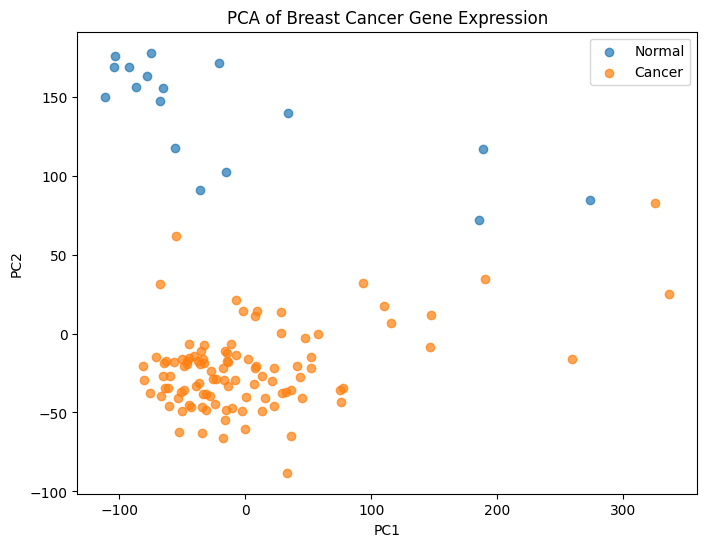

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for label in ["Normal", "Cancer"]:

    idx = y == label

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=label,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Breast Cancer Gene Expression")
plt.legend()


plt.savefig(
    "../figures/pca_breast_cancer.png",
    dpi=300,
    bbox_inches="tight"
)

## 5. Differential Expression Analysis




In [30]:
X = expr_t.drop("Label", axis=1)

normal = X[expr_t["Label"] == "Normal"]

cancer = X[expr_t["Label"] == "Cancer"]

print(normal.shape)
print(cancer.shape)

(17, 54675)
(104, 54675)


In [31]:
normal.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM1045191,5.640239,5.074866,4.191770,3.574706,2.312812,5.474018,7.392011,2.545487,6.363695,2.312812,...,13.900585,13.491092,14.891877,14.749976,10.053204,5.152432,7.779721,2.312812,2.312812,2.312812
GSM1045192,3.557696,4.984593,4.269061,4.065623,2.409371,5.246784,6.061380,2.312812,6.886877,2.366071,...,14.694493,14.482319,15.177010,15.107731,14.600338,10.401430,13.137754,2.312812,2.560414,2.312812
GSM1045193,3.132007,5.109481,4.131843,3.574706,2.312812,6.460169,5.862504,2.312812,4.953922,2.312812,...,14.528211,14.321748,15.195278,15.129354,14.114741,10.409900,13.120571,2.312812,2.460930,2.312812
GSM1045194,6.865108,5.473609,3.616546,3.574706,2.312812,5.146087,5.954431,2.312812,5.044880,2.312812,...,14.891396,14.796693,15.357952,15.360100,12.696520,7.505545,10.674244,2.312812,2.312812,2.312812
GSM1045195,4.955184,5.348400,4.296657,3.799293,2.349630,5.823408,7.679896,2.342446,5.468036,2.312812,...,14.307755,13.950866,15.133403,15.021234,10.747295,5.964108,8.416851,2.312812,2.312812,2.312812


In [32]:
cancer.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM1045208,7.996061,5.311982,4.041873,3.574706,2.312812,6.261753,6.231768,2.312812,6.302340,2.318849,...,13.591463,13.268729,14.496146,14.369979,10.339351,4.106648,7.798765,2.312812,2.312812,2.312812
GSM1045209,8.389665,5.588622,4.369333,3.574706,2.312812,5.311189,7.198395,2.312812,5.572859,2.312812,...,14.371413,13.958767,15.036319,14.877701,12.487950,7.555068,10.496528,2.312812,2.312812,2.312812
GSM1045210,7.883103,5.503518,3.945863,3.574706,2.312812,6.519589,7.018177,2.312812,6.934153,2.312812,...,14.506124,14.251371,15.229213,15.146143,10.253852,4.263207,7.399870,2.312812,2.312812,2.312812
GSM1045211,6.394748,4.900223,4.131843,3.574706,2.312812,4.823558,7.214731,2.312812,5.915115,2.312812,...,14.655426,14.384024,15.331037,15.175541,12.219683,6.858442,9.762540,2.312812,2.312812,2.312812
GSM1045212,7.460920,7.203254,6.046027,3.574706,2.312812,6.300663,5.050737,2.312812,9.360997,2.312812,...,11.813053,11.359787,13.089595,12.925096,7.780240,3.112584,5.482683,2.312812,2.312812,2.312812


In [33]:
normal_mean = normal.mean()
cancer_mean = cancer.mean()

In [34]:
logFC = cancer_mean - normal_mean
print(logFC)

ID_REF
1007_s_at          2.378070
1053_at            0.194795
117_at             0.262474
121_at            -0.052313
1255_g_at         -0.004742
                     ...   
AFFX-ThrX-5_at    -1.139831
AFFX-ThrX-M_at    -1.014078
AFFX-TrpnX-3_at    0.000925
AFFX-TrpnX-5_at   -0.019643
AFFX-TrpnX-M_at    0.001156
Length: 54675, dtype: float64


In [35]:
from scipy.stats import ttest_ind
p_values = []

for gene in X.columns:

    stat, p = ttest_ind(
        cancer[gene],
        normal[gene],
        equal_var=False,
        nan_policy="omit"
    )

    p_values.append(p)

c:\Users\Himanshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [36]:
results = pd.DataFrame({
    "Gene": X.columns,
    "logFC": logFC.values,
    "p_value": p_values
})

In [37]:
print(len(p_values))
print(results.shape)

54675
(54675, 3)


In [38]:
results["p_value"].isna().sum()

np.int64(96)

In [39]:
results.head()

,Gene,logFC,p_value
0,1007_s_at,2.378070,1.115771e-08
1,1053_at,0.194795,1.026515e-01
2,117_at,0.262474,5.037151e-02
3,121_at,-0.052313,4.124478e-01
4,1255_g_at,-0.004742,4.595456e-01


In [40]:
results = results.dropna()

In [41]:
results.shape

(54579, 3)

In [42]:
from statsmodels.stats.multitest import multipletests

results["adj_p"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

In [43]:
sig_genes = results[
    results["adj_p"] < 0.05
]

print(sig_genes.shape)

(17922, 4)


In [44]:
sig_genes = sig_genes.sort_values(
    "adj_p"
)

sig_genes.head(20)

,Gene,logFC,p_value,adj_p
15388,205941_s_at,3.592377,2.381322e-37,1.299702e-32
32816,223540_at,1.864932,3.469596e-30,9.468353e-26
54536,59697_at,1.678639,1.012895e-26,1.842760e-22
3549,1557289_s_at,2.127159,6.714834e-26,8.740946e-22
36895,227641_at,3.054369,8.007609e-26,8.740946e-22
26713,217428_s_at,3.562617,1.774348e-25,1.528631e-21
45711,236462_at,1.567491,1.960537e-25,1.528631e-21
13325,203878_s_at,3.404778,4.797246e-25,3.272861e-21
44787,235538_at,2.539549,6.616865e-25,4.012687e-21
45908,236659_x_at,1.379771,2.815849e-24,1.536862e-20


In [45]:
sig_genes.to_csv(
    "../results/significant_genes.csv",
    index=False
)

In [46]:
print(sig_genes.shape)
sig_genes.head()

(17922, 4)


,Gene,logFC,p_value,adj_p
15388,205941_s_at,3.592377,2.381322e-37,1.299702e-32
32816,223540_at,1.864932,3.469596e-30,9.468353e-26
54536,59697_at,1.678639,1.012895e-26,1.842760e-22
3549,1557289_s_at,2.127159,6.714834e-26,8.740946e-22
36895,227641_at,3.054369,8.007609e-26,8.740946e-22


## 6. Volcano Plot

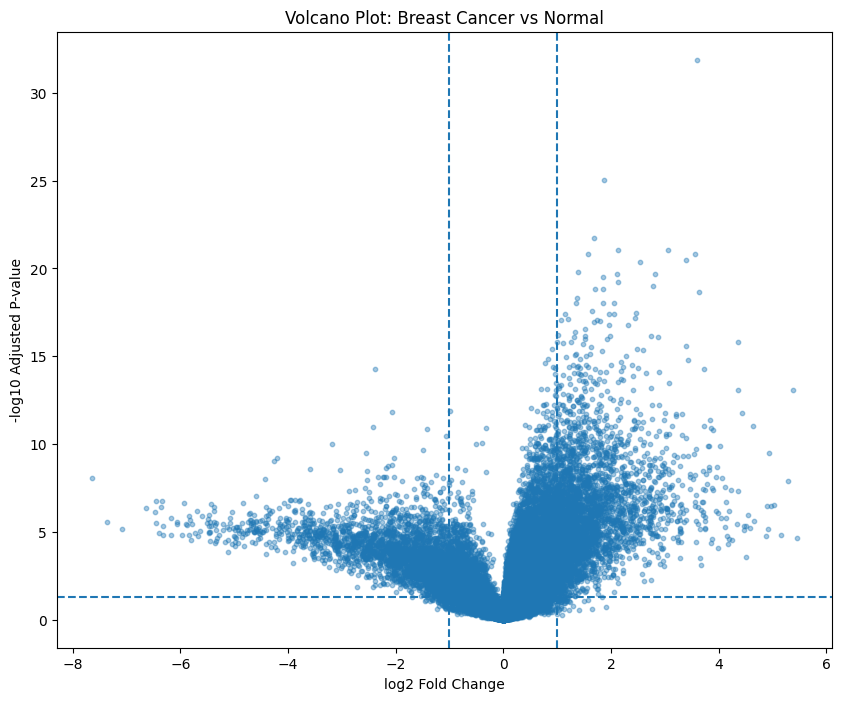

In [47]:
import numpy as np
import matplotlib.pyplot as plt

results["minus_log10_p"] = -np.log10(results["adj_p"])

plt.figure(figsize=(10,8))

plt.scatter(
    results["logFC"],
    results["minus_log10_p"],
    alpha=0.4,
    s=10
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Volcano Plot: Breast Cancer vs Normal")

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")

plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

plt.savefig(
    "../figures/volcano_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

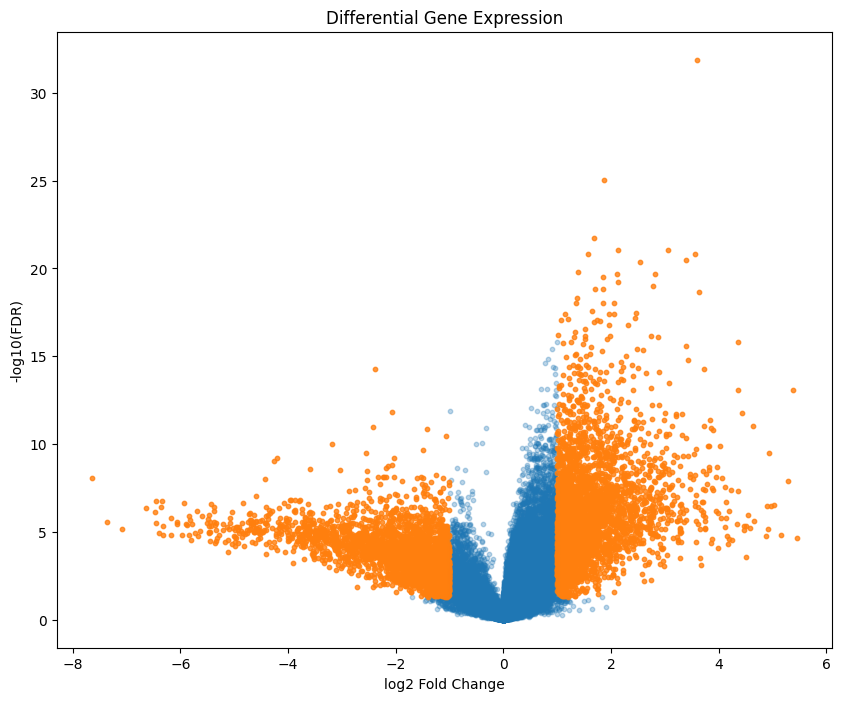

In [48]:
sig = (
    (results["adj_p"] < 0.05)
    &
    (abs(results["logFC"]) > 1)
)

plt.figure(figsize=(10,8))

plt.scatter(
    results.loc[~sig, "logFC"],
    results.loc[~sig, "minus_log10_p"],
    alpha=0.3,
    s=10
)

plt.scatter(
    results.loc[sig, "logFC"],
    results.loc[sig, "minus_log10_p"],
    alpha=0.8,
    s=10
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(FDR)")
plt.title("Differential Gene Expression")

plt.savefig(
    "../figures/volcano_plot_highlighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
top20 = sig_genes.nsmallest(20, "adj_p")

top20_genes = top20["Gene"]

heatmap_data = X[top20_genes]

heatmap_data.shape

(121, 20)

## 7. Heatmap of Significant Genes

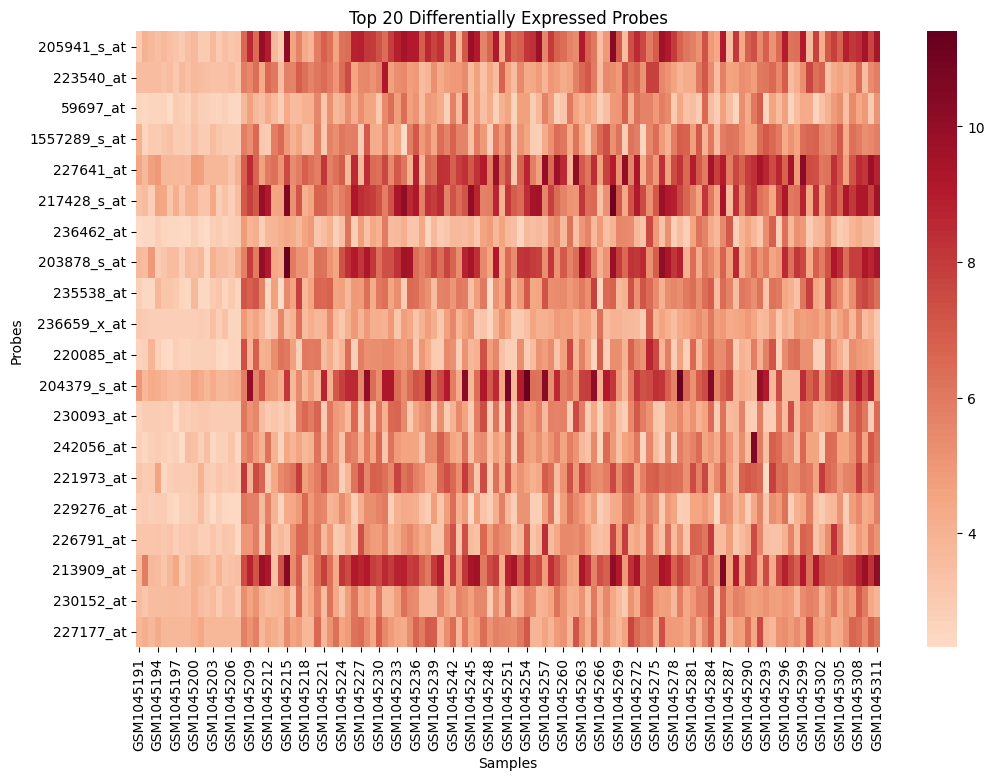

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data.T,
    cmap="RdBu_r",
    center=0
)

plt.title("Top 20 Differentially Expressed Probes")
plt.xlabel("Samples")
plt.ylabel("Probes")

plt.savefig(
    "../figures/heatmap_top20_genes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()